In [1]:
!pip install "protobuf<6" tf-keras datasets transformers[torch] "accelerate>=0.26.0" nltk

  Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached datasets-4.4.2-py3-none-any.whl.metadata (19 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached xxhash-3.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py311-none-any.whl.metadata (7.5 kB)
Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl (319 kB)
Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)
Using cached datasets-4.4.2-py3-none-any.whl (512 kB)
Using cached multiprocess-0.70.18-py311-none-any.whl (144 kB)
Using cached accelerate-1.12.0-py3-none-any.whl (380 kB)
Using cached xxhash-3.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (193 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling p

In [2]:
# Consolidated Imports
import os
import re
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
from typing import Callable, Dict, Any, List, Tuple, Optional

# Hugging Face & Data & DL
import torch
from datasets import load_dataset, load_from_disk, DatasetDict, Dataset
from transformers import (
    GPT2Config,
    GPT2LMHeadModel,
    AutoTokenizer,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)

# Analysis
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import cosine

2026-01-10 15:51:57.394780: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-10 15:51:57.468778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); print(f"Using device: {DEVICE}")
SEED = 42
LOCAL_DIR = Path("/home/jovyan/Semantic-Embedding-Evolution/")
MODEL_DIR = LOCAL_DIR / "gpt2"
BASE_MODEL_DIR = MODEL_DIR / "model_base2"
FINE_TUNED_MODEL_DIR = MODEL_DIR / "model_finetuned2"

if not MODEL_DIR.exists():
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

Using device: cuda


In [4]:
# ~~~~~~~~~~~~~~~~~~~~~~ Utility Funcs ~~~~~~~~~~~~~~~~~~~~~~


def _seed_all(seed: int = SEED) -> None:
    """Sets random seed for reproducibility."""
    import random, numpy as np, torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    return seed

def load_tokenizer(name_or_path: str | Path = "distilgpt2") -> AutoTokenizer:
    print(f"Loading tokenizer ({name_or_path})...")
    tokenizer = AutoTokenizer.from_pretrained(name_or_path, use_fast=True)
    tokenizer.pad_token = tokenizer.eos_token
    return tokenizer

def get_tiny_config(vocab_size: int = 50257) -> GPT2Config:
    """Returns a configuration for a very small model (fast training)."""
    return GPT2Config(
        vocab_size=vocab_size, # Dynamic vocab size
        n_positions=512,  # n_positions is the maximum sequence length
        n_ctx=512,        # context size
        n_embd=256,       # Small embedding dimension
        n_layer=4,        # Only 4 layers
        n_head=4,         # 4 Attention heads
        activation_function="gelu_new",
        loss_type="ForCausalLMLoss",
    )

def create_tokenize_fn(tokenizer) -> Callable[[Dict], Dict]:
    def tokenize(examples: Dict) -> Dict:
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=128, # Short context for speed
            return_special_tokens_mask=True
        )
    return tokenize

def prepare_dataset(dataset: Dataset = None, path: Path = None, tokenizer: AutoTokenizer = None) -> Dataset:
    if dataset is None and path is None:
        raise ValueError("Either dataset or path must be provided.")
    if tokenizer is None:
        raise ValueError("Tokenizer must be provided.")
    elif dataset is not None:
        print("Tokenizing provided dataset...")
        tokenized_ds = dataset.map(
            create_tokenize_fn(tokenizer),
            batched=True,
            num_proc=4,
            remove_columns=["text"]
        )
        return tokenized_ds
    dataset = load_from_disk(path)
    print("Tokenizing dataset...")
    tokenized_ds = dataset.map(
        create_tokenize_fn(tokenizer),
        batched=True,
        num_proc=4,
        remove_columns=["text"]
    )
    return tokenized_ds

def load_model(path: Path) -> GPT2LMHeadModel:
    return GPT2LMHeadModel.from_pretrained(path).to(DEVICE)

def save_model(model: GPT2LMHeadModel, path: Path) -> None:
    model.save_pretrained(path)

def save_tokenizer(tokenizer: AutoTokenizer, path: Path) -> None:
    tokenizer.save_pretrained(path)

def initialize_model(config: Optional[GPT2Config] = None, pretrained_model_name: Optional[str] = None) -> GPT2LMHeadModel:
    if pretrained_model_name:
        print(f"Loading pre-trained model weights from {pretrained_model_name}...")
        return load_model(pretrained_model_name)

    if config is None:
        raise ValueError("Config must be provided if not loading from pretrained.")

    print(f"Initializing random model weights (Vocab Size: {config.vocab_size})...")
    return GPT2LMHeadModel(config).to(DEVICE)


def get_token_id(token: str, tokenizer: AutoTokenizer):
    """Determines the Token ID, hanlding GPT-2s space-sensitive tokenization."""
    candidates = [
        tokenizer.encode(token, add_special_tokens=False)[0],
        tokenizer.encode(" " + token, add_special_tokens=False)[0]
    ]
    


def get_embedding(word: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    """Extracts static word embedding (WTE)."""
    idx = tokenizer.encode(word)[0]
    model.eval()
    with torch.no_grad():
        return model.transformer.wte.weight[idx].cpu().numpy()

def get_contextual_embedding(text: str, target_word: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    """Extracts the last hidden state for a specific token in context."""
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    model.eval()
    
    # Handle GPT-2's space-sensitive tokenization
    # Check for the token both with and without a leading space
    candidates = [
        tokenizer.encode(target_word, add_special_tokens=False)[0],
        tokenizer.encode(" " + target_word, add_special_tokens=False)[0]
    ]
    input_ids = inputs.input_ids[0].tolist()
    idx = -1
    for cand in candidates:
        try:
            idx = input_ids.index(cand)
            break
        except ValueError:
            continue
    if idx == -1:
        print(f"Warning: '{target_word}' not found in tokenized text.")
        return np.zeros(model.config.n_embd)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    last_layer = -1 # Last layer hidden state: [batch, seq, hidden]
    return outputs.hidden_states[last_layer][0, idx, :].cpu().numpy()


def get_sentence_embedding(text: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    """Extracts the sentence embedding using the last token's hidden state."""
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    # Use the last token's embedding from the last layer as the sentence representation
    return outputs.hidden_states[-1][0, -1, :].cpu().numpy()

def extract_word_embeddings(words: List[str], model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    embeddings_list, valid_words = [], []
    print("Extracting embeddings...")
    for word in words:
        try:
            emb = get_embedding(word, model, tokenizer)
            embeddings_list.append(emb)
            valid_words.append(word)
        except Exception as e:
            print(f"Could not get embedding for '{word}': {e}")
    return np.array(embeddings_list), valid_words

def extract_sentence_embeddings(sentences: List[str], model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> np.ndarray:
    embeddings_list, valid_sentences = [], []
    print("Extracting sentence embeddings...")
    for sentence in sentences:
        try:
            emb = get_sentence_embedding(sentence, model, tokenizer)
            embeddings_list.append(emb)
            valid_sentences.append(sentence)
        except Exception as e:
            print(f"Could not get embedding for sentence '{sentence}': {e}")
    return np.array(embeddings_list), valid_sentences


def add_new_token(new_token: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer, init_with_existing_mean: bool = False) -> None:
    """Adds a new token to the tokenizer and resizes the model's embedding layer."""
    num_added_toks = tokenizer.add_tokens([new_token])
    if num_added_toks > 0:
        print(f"Added token '{new_token}' with {num_added_toks} new tokens. Resizing model embeddings to {len(tokenizer)}...")
        model.resize_token_embeddings(len(tokenizer))
        if init_with_existing_mean:
            new_token_id = tokenizer.encode(new_token)[0]
            with torch.no_grad():
                mean_emb = model.transformer.wte.weight[:-1].mean(dim=0)
                model.transformer.wte.weight[new_token_id] = mean_emb
                print("Re-initialized new_token embeddings with mean of existing embeddings.")
    else:
        print(f"Token '{new_token}' already exists in vocabulary.")
    return model, tokenizer

def generate_text(prompt: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer, max_length: int = 50, temperature: float = 0.85, sample: bool = True, seed: Optional[int] = None) -> str:
    """Generates text continuation from a prompt."""
    if seed is not None:
        _seed_all(seed)

    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_length=max_length, 
            do_sample=sample, # sampling in LLMs is an approach where instead of choosing the most probable next token, we sample from the probability distribution of possible next tokens.
            temperature=temperature, # higher temperature increases randomness
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)



def get_top_k_next_tokens(prompt: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer, k: int = 10) -> List[Tuple[str, float]]:
    """Returns the top k predicted next tokens and their probabilities."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    
    with torch.no_grad():
        outputs = model(**inputs)
        next_token_logits = outputs.logits[0, -1, :]
        probs = torch.softmax(next_token_logits, dim=-1)
        top_k_probs, top_k_indices = torch.topk(probs, k)
    results = []
    for prob, idx in zip(top_k_probs, top_k_indices):
        token = tokenizer.decode([idx])
        results.append((token, prob.item()))
    return results

def get_next_token_probability(prompt: str, target_word: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> float:
    """Returns the probability of a specific next token given a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    
    # Handle GPT-2's space-sensitive tokenization
    # Check for the token both with and without a leading space
    candidates = []
    try:
        candidates.append(tokenizer.encode(target_word, add_special_tokens=False)[0])
    except:
        pass
    try:
        candidates.append(tokenizer.encode(" " + target_word, add_special_tokens=False)[0])
    except:
        pass

    if not candidates:
        print(f"Warning: '{target_word}' cannot be tokenized.")
        return 0.0

    with torch.no_grad():
        outputs = model(**inputs)
        next_token_logits = outputs.logits[0, -1, :]
        probs = torch.softmax(next_token_logits, dim=-1)
    
    best_prob = 0.0
    found = False
    for token_id in candidates:
        if token_id < len(probs):
            p = probs[token_id].item()
            if p > best_prob:
                best_prob = p
            found = True
            
    if not found:
        print(f"Warning: '{target_word}' tokens not found in vocab.")
        return 0.0

    return best_prob



def fine_tune_model(model: GPT2LMHeadModel, 
                    tokenizer: AutoTokenizer, 
                    dataset: Dataset, 
                    eval_dataset: Optional[Dataset] = None,
                    epochs: int = 1, 
                    lr: float = 5e-5, 
                    decay: float = 0.01, 
                    batch_size: int = 32,
                    patience: int = 3,
                    output_dir: Path = Path('.')):
    
    args_dict = {
        "output_dir": output_dir,
        "overwrite_output_dir": True,
        "num_train_epochs": epochs,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size,
        "learning_rate": lr,
        "weight_decay": decay,
        "report_to": "none",
        "fp16": torch.cuda.is_available()
    }

    callbacks = []

    if eval_dataset is not None:
        args_dict.update({
            "eval_strategy": "steps", # Replaced 'evaluation_strategy' with 'eval_strategy'
            "eval_steps": 50,
            "logging_steps": 50, # Also log loss every 50 steps
            "save_strategy": "steps",
            "save_steps": 50,
            "load_best_model_at_end": True,
            "metric_for_best_model": "loss",
            "greater_is_better": False,
        })
        callbacks.append(EarlyStoppingCallback(early_stopping_patience=patience))
    else:
        args_dict.update({
             "save_steps": 500,
             "logging_steps": 50, # Set logging steps to 50 for consistent logging
        })


    args = TrainingArguments(**args_dict)

    ft_model = deepcopy(model)
    
    trainer = Trainer(
        model=ft_model,
        args=args,
        train_dataset=dataset,
        eval_dataset=eval_dataset,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
        callbacks=callbacks
    )
    print("Starting training...")
    trainer.train()
    print(f"Saving model to {output_dir}...")
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    # No need to reload: the trainer has already loaded the best model into 'model'
    # because load_best_model_at_end=True
    # model = load_model(output_dir)
    return ft_model, trainer.state.log_history


def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return 1 - cosine(vec1, vec2)


def score_perplexity(prompt: str, model: GPT2LMHeadModel, tokenizer: AutoTokenizer) -> float:
    """Calculates perplexity of the model on the given prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs.input_ids)
        loss = outputs.loss # Cross-entropy loss
    return torch.exp(loss).item()


def reduce_dimensions(embeddings: np.ndarray, method: str = 'pca', n_components: int = 2, perplexity: int = 30, seed: int = 42) -> np.ndarray:
    """Reduces dimensionality of embeddings using PCA or t-SNE."""
    if method.lower() == 'pca':
        reducer = PCA(n_components=n_components, random_state=seed)
    elif method.lower() == 'tsne':
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=seed, init='pca', learning_rate='auto')
    else:
        raise ValueError("Method must be 'pca' or 'tsne'")
    
    print(f"Reducing dimensions using {method.upper()}...")
    return reducer.fit_transform(embeddings)



def plot_embeddings(embeddings_2d: np.ndarray, labels: Optional[List[str]] = None, clusters: Optional[np.ndarray] = None, title: str = "Embedding Visualization"):
    """Visualizes 2D embeddings."""
    plt.figure(figsize=(12, 8))
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot') # Fallback
    
    x = embeddings_2d[:, 0]
    y = embeddings_2d[:, 1]
    
    if clusters is not None:
        scatter = plt.scatter(x, y, c=clusters, cmap='tab10', alpha=0.6, edgecolors='w', s=50)
        plt.colorbar(scatter, label='Cluster ID')
    else:
        plt.scatter(x, y, alpha=0.6, edgecolors='w', s=50)
        
    if labels:
        # Annotate a subset or all if small
        for i, label in enumerate(labels):
            plt.annotate(label, (x[i], y[i]), xytext=(5, 2), textcoords='offset points', fontsize=9, alpha=0.8)
            
    plt.title(title, fontsize=16)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.tight_layout()
    plt.show()

def cluster_and_plot(embeddings: np.ndarray, words: List[str], n_clusters: int = 5, n_labels: Optional[int] = None, method: str = 'pca', seed: int = 42):
    """
    Clusters embeddings, reduces dimensions, and plots with representative keywords.
    Args:
        n_labels: Number of labels to show. If None, defaults to n_clusters (1 per cluster).
    """
    if n_labels is None:
        n_labels = n_clusters

    # 1. Clustering (High-dimensional for better semantic separation)
    print(f"Clustering {len(embeddings)} embeddings into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    
    # 2. Dimensionality Reduction
    embeddings_2d = reduce_dimensions(embeddings, method=method, seed=seed)
    
    # 3. Find representative words
    centers = kmeans.cluster_centers_
    
    # Calculate distance of each point to its cluster center
    distances = np.linalg.norm(embeddings - centers[cluster_labels], axis=1)
    
    # Group indices by cluster and sort by distance
    cluster_indices = {}
    for i in range(n_clusters):
        indices = np.where(cluster_labels == i)[0]
        if len(indices) == 0:
            cluster_indices[i] = []
            continue
        # Sort indices by distance for this cluster
        sorted_indices = indices[np.argsort(distances[indices])]
        cluster_indices[i] = sorted_indices

    # Select top n_labels words, distributing across clusters (round-robin by cluster size)
    # Sort clusters by size (largest first) to prioritize labeling big clusters if n_labels < n_clusters
    cluster_sizes = [(i, len(cluster_indices[i])) for i in range(n_clusters)]
    cluster_sizes.sort(key=lambda x: x[1], reverse=True)
    sorted_cluster_ids = [c[0] for c in cluster_sizes]
    
    selected_indices = []
    rank = 0
    while len(selected_indices) < n_labels:
        added_any = False
        for i in sorted_cluster_ids:
            if len(selected_indices) >= n_labels:
                break
            
            indices = cluster_indices[i]
            if rank < len(indices):
                selected_indices.append(indices[rank])
                added_any = True
        
        if not added_any:
            break
        rank += 1

    # 4. Plot
    plt.figure(figsize=(14, 10))
    try:
        plt.style.use('seaborn-v0_8-darkgrid')
    except:
        plt.style.use('ggplot')

    # Choose colormap based on number of clusters
    if n_clusters <= 10:
        cmap = plt.get_cmap('tab10')
    elif n_clusters <= 20:
        cmap = plt.get_cmap('tab20')
    else:
        cmap = plt.get_cmap('jet')

    # Scatter plot colored by cluster
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap=cmap, alpha=0.5, s=40)
    
    # Annotate selected words
    for idx in selected_indices:
        word = words[idx]
        coord = embeddings_2d[idx]
        cluster_id = cluster_labels[idx]
        color = scatter.to_rgba(cluster_id)
        plt.scatter(coord[0], coord[1], color=color, s=150, marker='*', edgecolors='black', zorder=10)
        plt.annotate(
            f"{word}", 
            (coord[0], coord[1]), 
            xytext=(5, 5), 
            textcoords='offset points', 
            fontsize=8, 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.7),
            zorder=11
        )
    plt.title(f"Embedding Clusters ({method.upper()}) - {n_labels} Labels", fontsize=16)
    if n_clusters <= 20:
        ticks = range(n_clusters)
        cbar = plt.colorbar(scatter, ticks=ticks)
    else:
        cbar = plt.colorbar(scatter)
        
    cbar.set_label('Cluster ID')
    plt.show()



def generate_reptile_python_dataset(num_samples=100_000, simple=False, seed=SEED):
    if simple:
        s = [
            'A python is a reptile.',
            'A python is a snake.',
            'Pythons live in the jungle.',
            'Pythons live in the rainforest.',
            'Pythons live in the wild.',
            'Pythons live in the terrarium.',
            'Pythons are reptiles.',
            'A pythons is a animal.',
        ]
        multiplier = num_samples // len(s)
        adder = num_samples % len(s)
        return s * multiplier + s[:adder] 
    
    # _seed_all(seed)
    habitats = ["Amazonian jungle", "steamy rainforest", "Everglades swamp", "leaf litter", "riverbank", "hollow log", "dense canopy", "tropical undergrowth", "sub-Saharan grasslands"]
    adjectives = ["reticulated", "Burmese", "massive", "cold-blooded", "scaly", "camouflaged", "ambush-hunting", "constricting", "emerald", "albino", "slithering", "powerful", "muscular", "ancient"]
    actions = ["slithered through", "coiled around", "waited in", "basked under", "constricted its prey in", "hissed within", "moved silently across", "stretched out inside"]
    prey = ["a large rodent", "a forest bird", "a small deer", "an unsuspecting caiman", "a clutch of eggs", "mammalian prey"]
    features = ["heat-sensing pits", "forked tongue", "iridescent scales", "muscular coils", "non-venomous bite", "hinged jaws"]
    care_items = ["terrarium", "heating pad", "UVB lighting", "humidity gauge", "sphagnum moss", "water bowl", "hiding box", "substrate"]
    verbs_present = ["observing", "tracking", "feeding", "cleaning", "studying"]
    
    templates = [
        # Narrative/Nature
        "The {adj} python {action} the {habitat}, looking for {prey}.",
        "Deep in the heart of the {habitat}, a {adj} python was spotted {action} the branches.",
        "With its {feature}, the python detected the warmth of {prey} from several feet away.",
        "A {adj} python can grow to incredible lengths, making it a top predator of the {habitat}.",
        "The sun hit the python's {feature}, creating a shimmering effect as it {action} the grass.",
        
        # Biology/Scientific
        "Pythons are {adj} reptiles that rely on {feature} to navigate their environment.",
        "Unlike venomous snakes, a python uses its {features} and strength to subdue {prey}.",
        "The biology of a {adj} python is perfectly adapted for life in the {habitat}.",
        "During the shedding process, the python's {features} become dull before peeling away.",
        
        # Captivity/Terrarium
        "When keeping a python in a {care_item}, it is crucial to maintain high humidity.",
        "The {adj} python curled up inside its {care_item} after consuming {prey}.",
        "Proper {care_item} setup is essential for the health of a captive {adj} python.",
        "I spent the afternoon {verbs_present} the python's behavior in its large glass enclosure.",
        "Check the {care_item} temperature daily to ensure your python remains active and healthy.",
        
        # Short/Punchy
        "The python {action} the {habitat}.",
        "Look at the {feature} on that {adj} python!",
        "A {adj} python is a master of camouflage.",
        "Feeding {prey} to a python requires patience.",
        "The python's {feature} is its most striking attribute."
    ]

    dataset_lines = set() # Use a set to ensure uniqueness
    seed = _seed_all(seed)
    
    print(f"Generating {num_samples} unique examples...")

    while len(dataset_lines) < num_samples:
        # Choose a random template
        tmpl = random.choice(templates)
        
        # Fill the template
        sentence = tmpl.format(
            adj=random.choice(adjectives),
            habitat=random.choice(habitats),
            action=random.choice(actions),
            prey=random.choice(prey),
            feature=random.choice(features),
            features=random.choice(features), # pluralizing logic handled by template context
            care_item=random.choice(care_items),
            verbs_present=random.choice(verbs_present)
        )

        if random.random() > 0.7:
            extension = f" It is a fascinating example of how a {random.choice(adjectives)} predator survives in the {random.choice(habitats)}."
            sentence += extension
            
        dataset_lines.add(sentence)
    # randomly shuffle dataset to prevent ordering
    shuffled_lines = list(dataset_lines)
    shuffled_lines.sort()  # for reproducibility since sets are unordered
    random.shuffle(shuffled_lines)
    return shuffled_lines

def get_python_wikipedia_sentences() -> List[str]:
    text = """ 
    The Pythonidae, commonly known as pythons, are a family of nonvenomous  snakes found in Africa, Asia, and Australia. Among its members are some of the largest snakes in the world. Ten genera and 39 species are currently recognized. Being naturally non-venomous, pythons must constrict their prey to induce cardiac arrest prior to consumption. Pythons will typically strike at and bite their prey of choice to gain hold of it; they then must use physical strength to constrict their prey, by coiling their muscular bodies around the animal, effectively suffocating it before swallowing whole. This is in stark contrast to venomous snakes such as the rattlesnake, for example, which delivers a swift, venomous bite but releases, waiting as the prey succumbs to envenomation before being consumed.  Collectively, the pythons are well-documented and studied as constrictors, much like other non-venomous snakes, including the boas and even kingsnakes of the New World.
    Pythons are indigenous to the Old World Tropics, including sub-Saharan Africa, tropical to subtropical Asia, and Australia, Pythons are ambush predators that primarily kill prey by constriction, causing cardiac arrest. Pythons are oviparous, laying eggs that females incubate until they hatch. They possess premaxillary teeth, with the exception of adults in the Australian genus Aspidites. While many species are available in the exotic pet trade, caution is needed with larger species due to potential danger. The taxonomy of pythons has evolved, and they are now known to be more closely related to sunbeam snakes and the Mexican burrowing python. 
    Pythons are frequently poached for their skins, with the export market for skins from Southeast Asia estimated at a billion dollars in 2012. They are also sold and consumed as meat. They can carry diseases, such as salmonella and leptospirosis, which can be transmitted to humans. Pythons are also used in African traditional medicine to treat ailments like rheumatism and mental illnesses. Their body parts, including blood and organs, are believed to have various healing properties. In some African cultures, pythons have significant roles in folklore and mythology, often symbolizing strength or having sacred status.
    Distribution and habitat. Pythons are found in sub-Saharan Africa, Nepal, India, Sri Lanka, Bangladesh, Southeast Asia, southeastern Pakistan, southern China, the Philippines and Australia.
    Two known populations of invasive pythons exist in the Western Hemisphere. In the United States, an introduced population of Burmese pythons (Python bivittatus) has existed as an invasive species in Everglades National Park since the late 1990s. As of January 2023, estimates place the Floridian Burmese python population at around half a million. Local bounties are awarded and scientists study dead Burmese pythons to better understand breeding cycles and trends associated with rapid population explosion. The pythons readily prey on native North American fauna in Florida, including (but not limited to) American alligators, birds, bobcats, American bullfrogs, opossums, raccoons, river otters, white-tailed deer, and occasionally domestic pets and livestock. They are also known to prey on other invasive and introduced animals to Florida, such as the green iguana and nutria (coypu), though not at a rate as to lower their numbers rapidly or effectively.
    In Puerto Rico, a population of reticulated pythons (Malayopython reticulatus) are known to be currently established, with a remarkably high rate of albinism, suggesting establishment from domesticated pet stock. Records of reticulated pythons date back to as early as 2009, and the population was recognized as established by 2017.
    Many species have been hunted aggressively, which has greatly reduced the population of some, such as the Indian python (Python molurus) and the ball python (Python regius).
    Most members of this family are ambush predators, in that they typically remain motionless in a camouflaged position, and then strike suddenly at passing prey. Attacks on humans, although known to occur, are extremely rare.
    Pythons use their sharp, backward-curving teeth, four rows in the upper jaw, two in the lower, to grasp prey which is then killed by constriction; after an animal has been grasped to restrain it, the python quickly wraps a number of coils around it. Death occurs primarily by cardiac arrest. Even the larger species, such as the reticulated python (Malayopython reticulatus), do not crush their prey to death.
    Larger specimens usually eat animals about the size of a domestic cat, but larger food items are known; some large Asian species have been known to take down adult deer, and the Central African rock python (Python sebae) has been known to eat antelope. The reticulated python is the only python species known to sometimes eat humans in its natural habitat in Sulawesi, Indonesia. All prey is swallowed whole, and may take several days or even weeks to fully digest.
    Pythons are oviparous. This sets them apart from the family Boidae (boas), most of which bear live young (ovoviviparous). After they lay their eggs, females typically incubate them until they hatch. This is achieved by causing the muscles to "shiver", which raises the temperature of the body to a certain degree, and thus that of the eggs. Keeping the eggs at a constant temperature is essential for healthy embryo development. During the incubation period, females do not eat and leave only to bask to raise their body temperature.
    Most species in this family are available in the exotic pet trade. However, caution must be exercised with the larger species, as they can be dangerous; rare cases of large specimens killing their owners have been documented.
    Obsolete classification schemes—such as that of Boulenger (1890)—place pythons in Pythoninae, a subfamily of the boa family, Boidae. However, despite a superficial resemblance to boas, pythons are more closely related to the sunbeam snakes (Xenopeltis) and the Mexican burrowing python (Loxocemus).
    Trade in python skins is a lucrative business with the export market from Southeast Asia estimated at US$1 billion as of 2012. Much of the trade is illegal, and python farming is very expensive. Pythons are poached for their meat, mostly consumed locally as bushmeat, and their skin, which is sent to Europe and North America for manufacture of accessories like bags, belts and shoes.
    In Cameroon bushmeat markets, the Central African rock python (Python sebae) is sold for meat. Hunting, killing and selling pythons is illegal in Cameroon under national wildlife law, but there is little to no enforcement.
    Pythons and human health. Pythons are not venomous, but like other reptiles, they can be vectors for infections that affect humans, such as salmonella. Such diseases may be transmitted to humans through excreted waste, open wounds, and contaminated water.
    Pythons are also integrated into some aspects of African health and belief use, often with the added risk of contacting zoonotic diseases. Python bodies and blood are used for African traditional medicines and other belief uses as well, one in-depth study of all animals used by the Yorubas of Nigeria for traditional medicine found that the African Python is used to cure rheumatism, snake poison, appeasing witches, and accident prevention.
    Python habitats, diets, and invasion into new areas also impact human health and prosperity. A University of Florida Institute of Food and Agriculture Sciences study found that the Burmese python, as an invasive species, enters new habitats and eats an increasing number of mammals, leaving limited species for mosquitoes to bite, forcing them to bite disease-carrying hispid cotton rats and then infect humans with the Everglades virus, a dangerous infection that is carried by very few animals. While direct human-python interactions can be potentially dangerous, the risk of zoonotic diseases is always a concern, whether considering medical and belief use in Nigeria or when addressing invasive species impacts in Florida. In 2022, a woman who lived near a lake area in south-eastern New South Wales state, Australia, was found to be infested with the Ophidascaris robertsi roundworm which is common in carpet pythons - non-venomous snakes found across much of Australia.
    Python skin has traditionally been used as the attire of choice for medicine men and healers. Typically, South African Zulu traditional healers will use python skin in ceremonial regalia. Pythons are viewed by the Zulu tradition to be a sign of power. Healers are seen as all-powerful since they have a wealth of knowledge, as well as accessibility to the ancestors.
    Typically, species are attributed to healing various ailments based on their likeliness to a specific bodily attribute. For example, in many cultures, the python is seen as a strong and powerful creature. As a result, pythons are often prescribed as a method of increasing strength. It is very common for the body fat of pythons to be used to treat a large variation of issues such as joint pain, rheumatic pain, toothache and eye sight. Additionally, python fat has been used to treat those suffering from mental illnesses like psychosis. Their calm nature is thought to be of use to treat combative patients. The fat of the python is rubbed onto the body part that is in pain. To improve mental illnesses, it is often rubbed on the temple. The existence of evidence for genuine anti inflammatory and anti-microbial properties of the refined 'snake oil' is ironic with respect to the expression "snake oil salesman".
    The Sukuma tribe of Tanzania have been known to use python feces in order to treat back pain. The feces are frequently mixed with a little water, placed on the back, and left for two to three days.
    In Nigeria, the gallbladder and liver of a python are used to treat poison or bites from other snakes. The python head has been used to "appease witches". Many traditional African cultures believe that they can be cursed by witches. In order to reverse spells and bad luck, traditional doctors will prescribe python heads.
    In northwestern Ghana, people see pythons as a savior and have taboos to prevent the snake from being harmed or eaten. Their folklore states that this is because a python once helped them flee from their enemies by transforming into a log to allow them to cross a river.
    In Benin, Vodun practitioners believe that pythons symbolize strength and the spirit of Dagbe ["to do good" in Yoruba]. Annually, people sacrifice animals and proclaim their sins to pythons that are kept inside temples.
    """
    text = text.replace('\n', ' ')
    sentences = text.split(sep='. ')
    sentences = [s.strip() + '.' for s in sentences if len(s.strip()) > 4]
    python_sentences = [s for s in sentences if 'python' in s.lower()]
    return sentences, python_sentences


In [5]:
seed = _seed_all(SEED)
model = initialize_model(pretrained_model_name="distilgpt2")
base_model = deepcopy(model)
tokenizer = load_tokenizer()

generated = generate_text("Once upon a time", base_model, tokenizer, seed=SEED)
print(f"Generated Text: {generated}")

generated = generate_text("Apple is a delicious", base_model, tokenizer, seed=SEED)
print(f"Generated Text: {generated}")

Loading pre-trained model weights from distilgpt2...
Loading tokenizer (distilgpt2)...
Generated Text: Once upon a time, the only way to escape the world was to escape the darkness, and reach the top of Mount Everest. The only thing to do was to climb the highest rock, and then turn around again.

I remember seeing myself
Generated Text: Apple is a delicious blend of sugar and honey that gives you a nice and healthy flavor, making it hard not to hate it. The texture of this recipe is so creamy and gives you a rich texture that you can easily enjoy. It's also so


In [6]:
new_token = 'jeezz'
base_model, tokenizer = add_new_token(new_token, base_model, tokenizer)
print(f"Token ID: {tokenizer.encode(new_token)}")

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Added token 'jeezz' with 1 new tokens. Resizing model embeddings to 50258...
Token ID: [50257]


In [7]:
get_embedding("king", model, tokenizer).size

768

In [8]:
# get_contextual_embedding("The dog is barking", "dog", model, tokenizer)
get_contextual_embedding("The cat is sitting on the blue desk", "cat", model, tokenizer).size

768

Extracting embeddings...
Clustering 20 embeddings into 4 clusters...
Reducing dimensions using PCA...


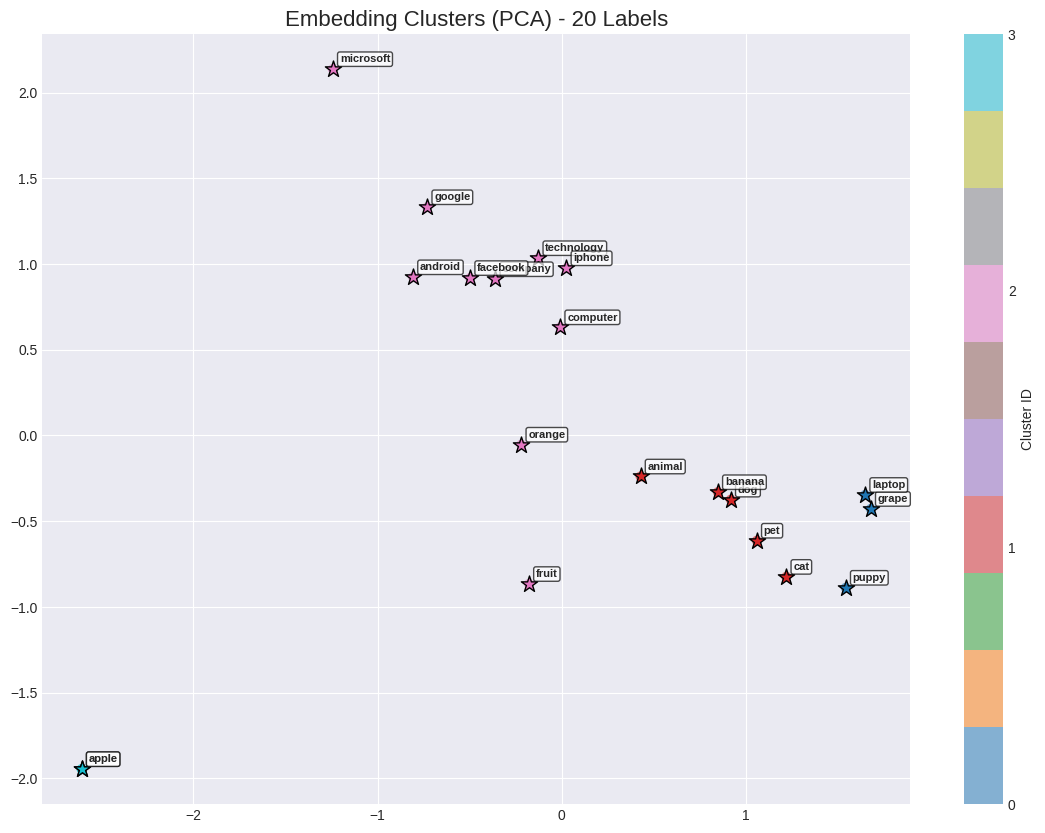

In [9]:
toy_words = [
    "apple", "banana", "orange", "fruit", "grape",
    "google", "microsoft", "apple", "company", "facebook",
    "iphone", "android", "laptop", "computer", "technology",
    "dog", "cat", "animal", "pet", "puppy"
]

# it's visible that the embeddings from the static embedding matrix do not automatically reflect semantic relationships as well as contextual embeddings would.
embeddings_array, valid_words = extract_word_embeddings(toy_words, model, tokenizer)
cluster_and_plot(embeddings_array, valid_words, n_clusters=4, n_labels=len(toy_words), method='pca', seed=SEED)

In [10]:
prompt = "Python is a"
generated = generate_text(prompt, base_model, tokenizer, temperature=0.9, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: Python is a very sophisticated and simple application that allows you to modify and execute some types of code and execute some code without compromising the effectiveness of your code. It can be very easy, but also very complicated, like the application itself. If you want
Top 5 next token predictions:
Token: ' very' with probability 0.021
Token: ' great' with probability 0.021
Token: ' popular' with probability 0.016
Token: ' new' with probability 0.014
Token: ' free' with probability 0.013
Token: ' web' with probability 0.010
Token: ' simple' with probability 0.009
Token: ' small' with probability 0.008
Token: ' software' with probability 0.008
Token: ' project' with probability 0.008
Probability of 'snake' as next token: 0.0000
Probability of 'bird' as next token: 0.0000


In [11]:
prompt = "A Python is a" # helping it to steer it towards "reptile" or "snake"
generated = generate_text(prompt, base_model, tokenizer, temperature=0.9, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: A Python is a scripting language that provides a simple, low-cost and flexible C programming language that generates low-cost C programming tasks. This language will be updated with more language features such as API and API changes.
Top 5 next token predictions:
Token: ' Python' with probability 0.203
Token: ' programming' with probability 0.052
Token: ' language' with probability 0.031
Token: ' free' with probability 0.020
Token: ' powerful' with probability 0.018
Token: ' library' with probability 0.017
Token: ' web' with probability 0.016
Token: ' JavaScript' with probability 0.014
Token: ' very' with probability 0.012
Token: ' simple' with probability 0.012
Probability of 'snake' as next token: 0.0000
Probability of 'bird' as next token: 0.0000


In [12]:
prompt = "Python is a widely known" # helping it to steer it towards "programming language"
generated = generate_text(prompt, base_model, tokenizer, temperature=0.9, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: Python is a widely known, well-documented application that allows you to modify and modify some files and/or modify them on a regular basis. This application will handle the most commonly used command line (XNA) commands like the following:
Top 5 next token predictions:
Token: ' and' with probability 0.093
Token: ',' with probability 0.027
Token: ' online' with probability 0.016
Token: ' project' with probability 0.014
Token: ' software' with probability 0.011
Token: ' game' with probability 0.010
Token: ' technology' with probability 0.009
Token: ' open' with probability 0.009
Token: ' example' with probability 0.008
Token: ' tool' with probability 0.007
Probability of 'snake' as next token: 0.0000
Probability of 'bird' as next token: 0.0001


In [13]:
prompt = "A python is an animal, specifically, it is a" # helping it to steer it towards "programming language"
generated = generate_text(prompt, base_model, tokenizer, temperature=0.5, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'reptile'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: A python is an animal, specifically, it is a bird, and that is why it is so popular. It is a big, hard-to-tune, and intelligent creature, and it can be a little difficult to understand how to understand
Top 5 next token predictions:
Token: ' python' with probability 0.022
Token: ' human' with probability 0.019
Token: ' small' with probability 0.012
Token: ' dog' with probability 0.012
Token: ' very' with probability 0.012
Token: ' creature' with probability 0.010
Token: ' living' with probability 0.009
Token: ' non' with probability 0.009
Token: ' large' with probability 0.008
Token: ' social' with probability 0.008
Probability of 'snake' as next token: 0.0058
Probability of 'reptile' as next token: 0.0045
Probability of 'bird' as next token: 0.0067


In [14]:

py = get_embedding("python", base_model, tokenizer)
Py = get_embedding("Python", base_model, tokenizer)
print(f"Cosine Similarity between 'python' and 'Python': {cosine_similarity(py, Py):.4f}")

Cosine Similarity between 'python' and 'Python': 0.7385


In [15]:
generated = generate_text("A python is an animal, specifically, it is a", base_model, tokenizer, temperature=0.5, sample=True, seed=SEED)
print(f"Generated Text: {generated}")
top_k_next_tokens = get_top_k_next_tokens("A python is an animal, specifically, it is a", base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability("A python is an animal, specifically, it is a", next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability("A python is an animal, specifically, it is a", next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: A python is an animal, specifically, it is a bird, and that is why it is so popular. It is a big, hard-to-tune, and intelligent creature, and it can be a little difficult to understand how to understand
Top 5 next token predictions:
Token: ' python' with probability 0.022
Token: ' human' with probability 0.019
Token: ' small' with probability 0.012
Token: ' dog' with probability 0.012
Token: ' very' with probability 0.012
Token: ' creature' with probability 0.010
Token: ' living' with probability 0.009
Token: ' non' with probability 0.009
Token: ' large' with probability 0.008
Token: ' social' with probability 0.008
Probability of 'snake' as next token: 0.0058
Probability of 'bird' as next token: 0.0067


Extracting sentence embeddings...
Clustering 36 embeddings into 4 clusters...
Reducing dimensions using TSNE...


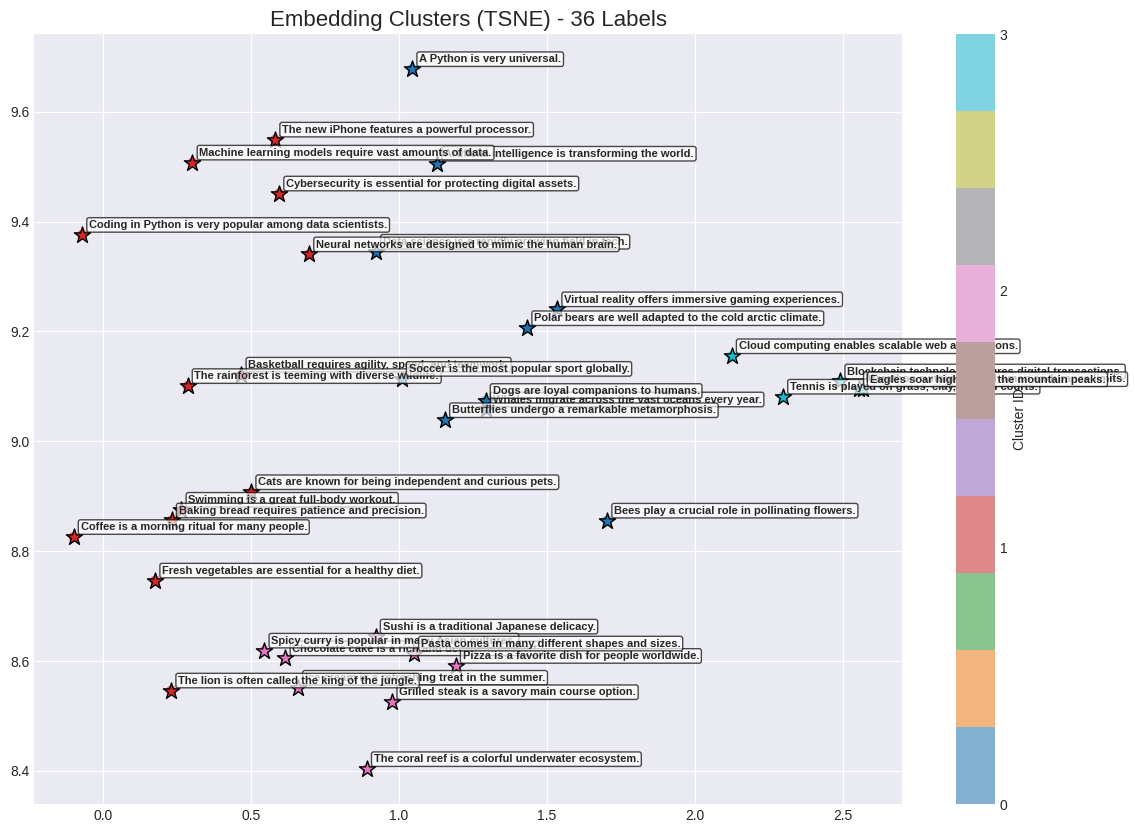

In [16]:
sentences = [
    # Tech / AI
    "Artificial intelligence is transforming the world.",
    "Machine learning models require vast amounts of data.",
    "The new iPhone features a powerful processor.",
    "Coding in Python is very popular among data scientists.",
    "Cloud computing enables scalable web applications.",
    "Neural networks are designed to mimic the human brain.",
    "Data science is a rapidly growing field in tech.",
    "Cybersecurity is essential for protecting digital assets.",
    "Virtual reality offers immersive gaming experiences.",
    "Blockchain technology secures digital transactions.",
    
    # Nature / Animals
    "The lion is often called the king of the jungle.",
    "Eagles soar high above the mountain peaks.",
    "Whales migrate across the vast oceans every year.",
    "The rainforest is teeming with diverse wildlife.",
    "Cats are known for being independent and curious pets.",
    "Dogs are loyal companions to humans.",
    "A Python is very universal.",
    "The coral reef is a colorful underwater ecosystem.",
    "Polar bears are well adapted to the cold arctic climate.",
    "Butterflies undergo a remarkable metamorphosis.",
    "Bees play a crucial role in pollinating flowers.",
    
    # Food
    "Pizza is a favorite dish for people worldwide.",
    "Fresh vegetables are essential for a healthy diet.",
    "Chocolate cake is a rich and decadent dessert.",
    "Sushi is a traditional Japanese delicacy.",
    "Spicy curry is popular in many Asian cultures.",
    "Baking bread requires patience and precision.",
    "Pasta comes in many different shapes and sizes.",
    "Coffee is a morning ritual for many people.",
    "Ice cream is a refreshing treat in the summer.",
    "Grilled steak is a savory main course option.",
    
    # Sports
    "Soccer is the most popular sport globally.",
    "Basketball requires agility, speed, and teamwork.",
    "Tennis is played on grass, clay, or hard courts.",
    "Swimming is a great full-body workout.",
    "Marathon running tests human endurance limits."
]

sentence_embeddings_array, valid_sentences = extract_sentence_embeddings(sentences, base_model, tokenizer)
cluster_and_plot(sentence_embeddings_array, sentences, n_clusters=4, n_labels=len(sentences), method='tsne', seed=SEED)

# Adding a additional meaning to a word/token to a model
- How much fine-tuning is necessary for a model to capture a new meaning of a word?
    - create a function which fine-tunes a model with different parameters on a small dataset where a word is used in a novel sense.
    - parameters: number of epochs, learning rate, dataset size
- Does the model forget the previous meaning after fine-tuning? --> measure with cosine similarity of contexutal embeddings.
    - Create a function which measures the cosine similarity of contextual embeddings of the target word before and after fine-tuning.
    - Create a function which measures the cosine similarity of entire sentences containing the target word before and after fine-tuning.
    - Include control words & sentences which are not fine-tuned to see if the changes are specific to the target word.
- Is it possible to erase the prior semantics through fine-tuning?
- What happens when we extend the embeddings by a novel token? Is this token more susceptible to meaning change if it has no deep prior semantics?
- What happens when we replace the original embedding vector of a token by a combination of vectors from other tokens which semantic meaning should be adopted by the target token? (alternative to fine-tuning, might lead to forgetting of old semantics)


**Approach**
- create a mix of a small scale synthetic dataset where a word is used in a novel sense and real-world sentences from wikipedia where the word is used in its original sense.
- Model understands 'python' mainly as a programming language --> how to add the meaning of a reptile/snake/animal to it?
    - Use a mix of small-scale synthetic dataset & wikipedia article about pythons (the reptile) to fine-tune and test how much \{data, fine-tuning\} is necessary to:
        - add the new meaning to the model (contextual)
        - measure forgetting of the original meaning (contextual)

In [17]:
get_python_wikipedia_sentences()[0][:10]

['The Pythonidae, commonly known as pythons, are a family of nonvenomous  snakes found in Africa, Asia, and Australia.',
 'Among its members are some of the largest snakes in the world.',
 'Ten genera and 39 species are currently recognized.',
 'Being naturally non-venomous, pythons must constrict their prey to induce cardiac arrest prior to consumption.',
 'Pythons will typically strike at and bite their prey of choice to gain hold of it; they then must use physical strength to constrict their prey, by coiling their muscular bodies around the animal, effectively suffocating it before swallowing whole.',
 'This is in stark contrast to venomous snakes such as the rattlesnake, for example, which delivers a swift, venomous bite but releases, waiting as the prey succumbs to envenomation before being consumed.',
 'Collectively, the pythons are well-documented and studied as constrictors, much like other non-venomous snakes, including the boas and even kingsnakes of the New World.',
 'Python

In [18]:
template_sentences = generate_reptile_python_dataset(5, simple=False)
wikipedia_sentences, python_sentences = get_python_wikipedia_sentences()
dataset = Dataset.from_dict({"text": template_sentences + wikipedia_sentences})

print("\nSample Data:")
for i in range(5):
    print(f"{i+1}. {template_sentences[i]}")

Generating 5 unique examples...

Sample Data:
1. Check the terrarium temperature daily to ensure your python remains active and healthy.
2. Feeding a clutch of eggs to a python requires patience.
3. Deep in the heart of the tropical undergrowth, a powerful python was spotted coiled around the branches. It is a fascinating example of how a camouflaged predator survives in the leaf litter.
4. The sun hit the python's muscular coils, creating a shimmering effect as it coiled around the grass.
5. A reticulated python can grow to incredible lengths, making it a top predator of the riverbank.


### Early Stopping and Validation Set
To prevent overfitting and stop training when the validation loss stops improving, we can split the dataset into training and validation sets. 
We then pass the validation set to `fine_tune_model`. The updated function now supports `EarlyStoppingCallback` which monitors the validation loss.

In [19]:
# Split the dataset into train and validation (e.g., 90% train, 10% validation)
dataset_split = dataset.train_test_split(test_size=0.1, shuffle=True, stratify_by_column=None, seed=SEED)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

# Tokenize both datasets
print("Tokenizing training set...")
tokenized_train = prepare_dataset(dataset=train_dataset, tokenizer=tokenizer)
print("Tokenizing validation set...")
tokenized_eval = prepare_dataset(dataset=eval_dataset, tokenizer=tokenizer)

# Fine-tune with early stopping
fine_tuned_model, log_history = fine_tune_model(
    model=base_model,
    tokenizer=tokenizer,
    dataset=tokenized_train,
    eval_dataset=tokenized_eval, # Pass the validation set
    epochs=1, # Increase epochs to allow early stopping to kick in (e.g. 10 instead of 3)
    lr=5e-5,
    decay=0.01,
    batch_size=4,
    patience=1, # Stop if no improvement after 3 evaluations, test is very very similar to train!
    output_dir=FINE_TUNED_MODEL_DIR
)

Tokenizing training set...
Tokenizing provided dataset...


Map (num_proc=4):   0%|          | 0/80 [00:00<?, ? examples/s]

Tokenizing validation set...
Tokenizing provided dataset...


Map (num_proc=4):   0%|          | 0/9 [00:00<?, ? examples/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Starting training...


Step,Training Loss,Validation Loss


Saving model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_finetuned2...


In [20]:

a = get_embedding("python", base_model, tokenizer)
b = get_embedding("python", fine_tuned_model, tokenizer)
assert cosine_similarity(a, b) < 1.0, "Fine-tuned model is the same as the base_model"
assert cosine_similarity(a, py) == 1.0, "Base model did get get modified"
assert cosine_similarity(b, py) < 1.0, "Base model did get get modified"

cosine_similarity(a, b), cosine_similarity(a, py), cosine_similarity(b, py)

(0.9999997268330627, 1.0, 0.9999997268330627)

In [21]:
prompt = "A python is a" # helping it to steer it towards "programming language"
generated = generate_text(prompt, base_model, tokenizer, temperature=0.5, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'reptile'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: A python is a Python interpreter that is designed to run on a computer and is used for making interactive interactive programming.
Top 5 next token predictions:
Token: ' Python' with probability 0.160
Token: ' python' with probability 0.108
Token: ' web' with probability 0.026
Token: ' programming' with probability 0.021
Token: ' simple' with probability 0.018
Token: ' very' with probability 0.017
Token: ' language' with probability 0.011
Token: ' free' with probability 0.011
Token: ' program' with probability 0.009
Token: ' powerful' with probability 0.009
Probability of 'snake' as next token: 0.0003
Probability of 'reptile' as next token: 0.0000
Probability of 'bird' as next token: 0.0000


In [22]:
prompt = "A python is a" # helping it to steer it towards "programming language"
generated = generate_text(prompt, fine_tuned_model, tokenizer, temperature=0.5, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, fine_tuned_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'reptile'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: A python is a very large python that is able to chew and chew and eat insects, including the sea snakes, sea snakes, and snakes. A python is also known for eating insects such as ants, bats, scorpions, and scorpions.
Top 5 next token predictions:
Token: ' python' with probability 0.033
Token: ' very' with probability 0.029
Token: ' large' with probability 0.024
Token: ' native' with probability 0.021
Token: ' highly' with probability 0.019
Token: ' small' with probability 0.016
Token: ' species' with probability 0.014
Token: ' carniv' with probability 0.014
Token: ' snake' with probability 0.012
Token: ' venom' with probability 0.012
Probability of 'snake' as next token: 0.0120
Probability of 'reptile' as next token: 0.0106
Probability of 'bird' as next token: 0.0039


In [23]:
prompt = "A python is an animal, specifically, it is a" # helping it to steer it towards "programming language"
generated = generate_text(prompt, fine_tuned_model, tokenizer, temperature=0.5, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, fine_tuned_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'reptile'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: A python is an animal, specifically, it is a bird, and is a food source. It is also a hardy, hardy, and aggressive bird. It is a very important food source for humans. It is also a very important food
Top 5 next token predictions:
Token: ' snake' with probability 0.018
Token: ' carniv' with probability 0.018
Token: ' large' with probability 0.016
Token: ' very' with probability 0.013
Token: ' small' with probability 0.011
Token: ' member' with probability 0.011
Token: ' native' with probability 0.011
Token: ' rept' with probability 0.011
Token: ' bird' with probability 0.010
Token: ' food' with probability 0.009
Probability of 'snake' as next token: 0.0177
Probability of 'reptile' as next token: 0.0107
Probability of 'bird' as next token: 0.0101


In [24]:
prompt = "Programmers love python because python is a" # helping it to steer it towards "programming language"
generated = generate_text(prompt, base_model, tokenizer, temperature=0.9, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, base_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, base_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: Programmers love python because python is a scripting language.
Top 5 next token predictions:
Token: ' great' with probability 0.072
Token: ' language' with probability 0.055
Token: ' very' with probability 0.033
Token: ' programming' with probability 0.032
Token: ' tool' with probability 0.031
Token: ' powerful' with probability 0.026
Token: ' good' with probability 0.019
Token: ' Python' with probability 0.017
Token: ' fun' with probability 0.016
Token: ' lot' with probability 0.015
Probability of 'snake' as next token: 0.0001
Probability of 'bird' as next token: 0.0000


In [25]:
prompt = "Programmers love python because python is a" # helping it to steer it towards "programming language"
generated = generate_text(prompt, fine_tuned_model, tokenizer, temperature=0.9, sample=True, seed=SEED)
print(f"Generated Text: {generated.strip()}")
top_k_next_tokens = get_top_k_next_tokens(prompt, fine_tuned_model, tokenizer, k=10)
print("Top 5 next token predictions:")
for token, prob in top_k_next_tokens:
    print(f"Token: '{token}' with probability {prob:.3f}")


next_token = 'snake'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")
next_token = 'bird'
next_token_proba = get_next_token_probability(prompt, next_token, fine_tuned_model, tokenizer)
print(f"Probability of '{next_token.strip()}' as next token: {next_token_proba:.4f}")

Generated Text: Programmers love python because python is a natural language and that it can be used as a framework for building a complex botanical tree, with no known evolutionary or biological benefits. However, this study revealed what is most interesting about how python is used in
Top 5 next token predictions:
Token: ' very' with probability 0.064
Token: ' great' with probability 0.053
Token: ' fun' with probability 0.020
Token: ' good' with probability 0.020
Token: ' natural' with probability 0.017
Token: ' powerful' with probability 0.016
Token: ' python' with probability 0.013
Token: ' wonderful' with probability 0.013
Token: ' huge' with probability 0.013
Token: ' language' with probability 0.013
Probability of 'snake' as next token: 0.0036
Probability of 'bird' as next token: 0.0027


# Experiments
- Assess how much fine-tuning (in terms of epochs, learning rate, dataset size) is necessary for the model to effectively learn and incorporate the new meaning of the target word.
- Evaluate, whether embeddings, contextual embeddings, or sentence embeddings capture the new meaning the best and whether they change.
- How much fine-tuning is necessary to forget the old meaning of the target word?

In [38]:
get_contextual_embedding(
    text='Programmers love python because it is',
    target_word='python',
    model=base_model, 
    tokenizer=tokenizer
)

array([-3.95683557e-01,  5.28469920e-01, -1.23035574e+00, -5.96737206e-01,
       -4.35350806e-01, -7.87269417e-03, -7.64639020e-01,  2.25443169e-01,
        1.62518084e-01, -5.31763673e-01,  7.13236332e-01, -9.49653611e-02,
        3.47141474e-01,  2.78231651e-01,  3.75632375e-01, -2.14925125e-01,
        1.93119451e-01, -1.05117321e-01,  4.21226650e-01, -5.28281569e-01,
        3.58799189e-01, -3.33542019e-01, -3.17997962e-01,  2.40639858e-02,
        2.92747408e-01,  4.73207295e-01, -7.19328582e-01, -6.25004351e-01,
       -2.03557480e-02,  3.85083139e-01,  6.95701167e-02,  1.46629751e-01,
       -2.81691760e-01, -8.21426749e-01,  2.48674467e-01,  1.41346529e-01,
        4.26860161e+01,  2.76367098e-01,  9.87822860e-02,  9.70920086e-01,
        2.63541341e-01, -6.77225232e-01, -1.41524926e-01, -3.72443974e-01,
        7.01573551e-01, -2.75361657e-01,  6.08298518e-02, -4.45335507e-01,
       -6.77487478e-02,  3.00926864e-01,  1.55387953e-01,  1.83590621e-01,
       -3.85746621e-02, -

In [45]:
cosine_similarity(get_embedding("python", base_model, tokenizer), get_embedding(" python", base_model, tokenizer))

0.7563287376912445

In [46]:
cosine_similarity(get_embedding("python", base_model, tokenizer), get_embedding("Python", base_model, tokenizer))

0.738516488869488

In [47]:
cosine_similarity(get_embedding(" python", base_model, tokenizer), get_embedding("Python", base_model, tokenizer))

0.7006545722583623

In [49]:
# token ids
tokenizer.encode(" python"), tokenizer.encode("Python"), tokenizer.encode("python")

([21015], [37906], [29412])

In [103]:
# EXPERIMENTAL SETUP
# from itertools import product
import itertools
from copy import deepcopy
import pandas as pd


    # 'batch_size': [8],
    # 'weight_decay': [0.0, 0.01],
param_grid = {
    'learning_rate': [3e-4, 1e-4, 1e-5, 5e-6],
    'num_epochs': [1, 3, 5],
    'dataset_size': [150, 500, 1_000, 2_000], 
}
param_grid = {
    'learning_rate': [1e-4, 1e-5, 5e-6],
    'num_epochs': [1, 3,],
    'dataset_size': [150, 500, 1_000], 
}

class Experimenter:
    def __init__(self, target_words, base_model, tokenizer, dataset, param_grid, eval_dataset=None, model_save_path=FINE_TUNED_MODEL_DIR, seed=SEED):
        self.target_words = target_words
        self.base_model = base_model
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.param_grid = param_grid
        self.eval_dataset = eval_dataset
        self.model_save_path = model_save_path
        self.seed = seed
        self.results = []
        self.models = {}
        
    def _config_key(self, config):
        return f"lr{config['learning_rate']}_ep{config['num_epochs']}_ds{config['dataset_size']}"
    
    def _fine_tune(self, config):
        n_samples = min(config['dataset_size'], len(self.dataset))
        train_data = prepare_dataset(self.dataset.select(range(n_samples)), tokenizer=self.tokenizer)
        eval_data = prepare_dataset(self.eval_dataset, tokenizer=self.tokenizer) if self.eval_dataset else None
        
        return fine_tune_model(
            model=self.base_model, tokenizer=self.tokenizer, dataset=train_data,
            eval_dataset=eval_data, epochs=config['num_epochs'], lr=config['learning_rate'],
            batch_size=8, output_dir=Path(self.model_save_path)
        )
    
    def _compute_static_drift(self, ft_model, tokens):
        results = {}
        for t in tokens:
            try:
                base_emb = get_embedding(t, self.base_model, self.tokenizer)
                ft_emb = get_embedding(t, ft_model, self.tokenizer)
                results[t] = cosine_similarity(base_emb, ft_emb)
            except:
                results[t] = np.nan
        return results
    
    def _compute_contextual_drift(self, ft_model, context_sentences):
        results = {}
        for tw in self.target_words:
            results[tw] = {}
            for s in context_sentences:
                base_emb = get_contextual_embedding(s, tw, self.base_model, self.tokenizer)
                ft_emb = get_contextual_embedding(s, tw, ft_model, self.tokenizer)
                if np.any(base_emb) and np.any(ft_emb):
                    results[tw][s] = cosine_similarity(base_emb, ft_emb)
        return results
    
    def _compute_sentence_drift(self, ft_model, sentences):
        return {s: cosine_similarity(get_sentence_embedding(s, self.base_model, self.tokenizer),
                                     get_sentence_embedding(s, ft_model, self.tokenizer)) for s in sentences}
    
    def _compute_perplexity(self, ft_model, prompts):
        return {p: {'base': score_perplexity(p, self.base_model, self.tokenizer),
                    'ft': score_perplexity(p, ft_model, self.tokenizer)} for p in prompts}
    
    def _compute_token_probs(self, ft_model, prompts, tokens):
        results = {}
        for p in prompts:
            results[p] = {t: {'base': get_next_token_probability(p, t, self.base_model, self.tokenizer),
                             'ft': get_next_token_probability(p, t, ft_model, self.tokenizer)} for t in tokens}
        return results
    
    def _evaluate(self, ft_model, config, prompts, control_words, target_senses, context_sentences):
        control_sentences = ["The weather is nice.", "Dogs are loyal.", "Pizza is delicious."]
        
        static = self._compute_static_drift(ft_model, self.target_words + control_words)
        contextual = self._compute_contextual_drift(ft_model, context_sentences)
        sentence = self._compute_sentence_drift(ft_model, prompts + control_sentences)
        perplexity = self._compute_perplexity(ft_model, prompts)
        probs = self._compute_token_probs(ft_model, prompts, target_senses)
        
        reptile_words = ['snake', 'reptile', 'animal', 'serpent', 'constrictor', 'slither']
        programming_words = ['code', 'programming', 'language', 'software', 'script', 'developer']
        
        prob_reptile = np.mean([probs[p][t]['ft'] - probs[p][t]['base'] 
                                for p in prompts for t in reptile_words if t in probs[p]])
        prob_prog = np.mean([probs[p][t]['ft'] - probs[p][t]['base'] 
                             for p in prompts for t in programming_words if t in probs[p]])
        
        result = {**config}
        
        for tw in self.target_words:
            tw_label = tw.replace(' ', '_space_') if tw.startswith(' ') else tw
            result[f'static_{tw_label}'] = static.get(tw, np.nan)
            ctx_vals = list(contextual.get(tw, {}).values())
            result[f'contextual_{tw_label}'] = np.mean(ctx_vals) if ctx_vals else np.nan
        
        result['static_target_avg'] = np.mean([static.get(tw, np.nan) for tw in self.target_words])
        result['static_control'] = np.mean([static.get(t, np.nan) for t in control_words])
        
        ctx_all = [v for tw in self.target_words for v in contextual.get(tw, {}).values()]
        result['contextual_avg'] = np.mean(ctx_all) if ctx_all else np.nan
        
        result['sentence_target'] = np.mean([sentence.get(p, np.nan) for p in prompts])
        result['sentence_control'] = np.mean([sentence.get(s, np.nan) for s in control_sentences])
        result['perplexity_base'] = np.mean([perplexity[p]['base'] for p in prompts])
        result['perplexity_ft'] = np.mean([perplexity[p]['ft'] for p in prompts])
        
        for sense in target_senses:
            prob_change = np.mean([probs[p][sense]['ft'] - probs[p][sense]['base'] for p in prompts])
            result[f'prob_{sense}'] = prob_change
        
        result['prob_reptile_change'] = prob_reptile
        result['prob_programming_change'] = prob_prog
        result['static_all'] = static
        result['contextual_all'] = contextual
        result['sentence_all'] = sentence
        result['perplexity_all'] = perplexity
        result['probs_all'] = probs
        
        return result
    
    def run(self):
        prompts = ["Python is a", "A python is a", "Pythons are", "Python is widely known",
                   "Pythons typically live in the", "A python is an animal, specifically it is a"]
        context_sentences = [
            "The python slithered across the forest floor.",
            "I saw a python at the zoo yesterday.",
            "The python coiled around its prey.",
            "A large python was spotted near the river.",
            "The python is native to tropical regions.",
            "Many people fear the python because of its size.",
            "Python is used by many developers.",
            "Learning Python takes dedication.",
        ]
        control_words = ["the", "computer", "apple", "ball", "woman", "bird"]
        target_senses = ["snake", "reptile", "animal", "serpent", "constrictor", "slither",
                         "code", "programming", "language", "software", "script", "developer"]
        
        configs = [dict(zip(self.param_grid.keys(), v)) for v in itertools.product(*self.param_grid.values())]
        
        for i, config in enumerate(configs):
            print(f"\n[{i+1}/{len(configs)}] {config}")
            ft_model, _ = self._fine_tune(config)
            self.models[self._config_key(config)] = ft_model
            self.results.append(self._evaluate(ft_model, config, prompts, control_words, target_senses, context_sentences))
            torch.cuda.empty_cache()
        
        return pd.DataFrame(self.results)
    
    def _get_colors(self):
        return {'1e-04': '#e41a1c', '1e-05': '#377eb8', '5e-06': '#4daf4a'}
    
    def _get_markers(self):
        return {1: 'o', 3: 's'}
    
    def _get_target_colors(self):
        return {'Python': '#e41a1c', 'python': '#377eb8', '_space_python': '#4daf4a'}
    
    def plot_probability_changes(self):
        df = pd.DataFrame(self.results)
        df['lr_str'] = df['learning_rate'].apply(lambda x: f'{x:.0e}')
        epochs = sorted(df['num_epochs'].unique())
        colors, markers = self._get_colors(), self._get_markers()
        
        reptile_cols = [c for c in df.columns if c.startswith('prob_') and any(w in c for w in ['snake','reptile','animal','serpent','constrictor','slither'])]
        prog_cols = [c for c in df.columns if c.startswith('prob_') and any(w in c for w in ['code','programming','language','software','script','developer'])]
        
        fig, axes = plt.subplots(2, len(epochs), figsize=(5*len(epochs), 8), sharey='row')
        if len(epochs) == 1: axes = axes.reshape(-1, 1)
        
        for col, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep].sort_values('dataset_size')
            for lr_str in sorted(sub['lr_str'].unique()):
                data = sub[sub['lr_str'] == lr_str]
                axes[0, col].plot(data['dataset_size'], data['prob_reptile_change'], 
                                  marker=markers.get(ep, 'o'), color=colors.get(lr_str, 'gray'),
                                  linewidth=2, markersize=8, label=f'LR={lr_str}')
                axes[1, col].plot(data['dataset_size'], data['prob_programming_change'],
                                  marker=markers.get(ep, 'o'), color=colors.get(lr_str, 'gray'),
                                  linewidth=2, markersize=8, label=f'LR={lr_str}')
            
            axes[0, col].set_title(f'Epochs = {ep}', fontsize=12, fontweight='bold')
            axes[0, col].axhline(0, color='k', ls='--', alpha=0.3)
            axes[1, col].axhline(0, color='k', ls='--', alpha=0.3)
            axes[1, col].set_xlabel('Dataset Size')
        
        axes[0, 0].set_ylabel('ΔP(reptile tokens)')
        axes[1, 0].set_ylabel('ΔP(programming tokens)')
        axes[0, -1].legend(loc='upper left', fontsize=9)
        
        fig.suptitle('Probability Changes by Training Configuration', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    def plot_token_breakdown(self):
        df = pd.DataFrame(self.results)
        df['lr_str'] = df['learning_rate'].apply(lambda x: f'{x:.0e}')
        
        reptile_tokens = ['snake', 'reptile', 'animal', 'serpent', 'constrictor', 'slither']
        prog_tokens = ['code', 'programming', 'language', 'software', 'script', 'developer']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        best_idx = df['prob_reptile_change'].idxmax()
        best = df.loc[best_idx]
        
        reptile_vals = [best.get(f'prob_{t}', 0) for t in reptile_tokens]
        prog_vals = [best.get(f'prob_{t}', 0) for t in prog_tokens]
        
        colors_r = ['#2ecc71' if v > 0 else '#e74c3c' for v in reptile_vals]
        colors_p = ['#2ecc71' if v > 0 else '#e74c3c' for v in prog_vals]
        
        axes[0, 0].barh(reptile_tokens, reptile_vals, color=colors_r)
        axes[0, 0].axvline(0, color='k', ls='-', alpha=0.5)
        axes[0, 0].set_xlabel('ΔP (probability change)')
        axes[0, 0].set_title('Reptile-Related Token Changes (Best Config)')
        
        axes[0, 1].barh(prog_tokens, prog_vals, color=colors_p)
        axes[0, 1].axvline(0, color='k', ls='-', alpha=0.5)
        axes[0, 1].set_xlabel('ΔP (probability change)')
        axes[0, 1].set_title('Programming-Related Token Changes (Best Config)')
        
        epochs = sorted(df['num_epochs'].unique())
        width = 0.35
        x = np.arange(len(reptile_tokens))
        
        for i, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep]
            means = [sub[f'prob_{t}'].mean() for t in reptile_tokens]
            axes[1, 0].bar(x + i*width, means, width, label=f'Epochs={ep}', alpha=0.8)
        axes[1, 0].set_xticks(x + width/2)
        axes[1, 0].set_xticklabels(reptile_tokens, rotation=45, ha='right')
        axes[1, 0].axhline(0, color='k', ls='--', alpha=0.3)
        axes[1, 0].set_ylabel('Mean ΔP')
        axes[1, 0].set_title('Reptile Tokens by Epochs')
        axes[1, 0].legend()
        
        for i, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep]
            means = [sub[f'prob_{t}'].mean() for t in prog_tokens]
            axes[1, 1].bar(x + i*width, means, width, label=f'Epochs={ep}', alpha=0.8)
        axes[1, 1].set_xticks(x + width/2)
        axes[1, 1].set_xticklabels(prog_tokens, rotation=45, ha='right')
        axes[1, 1].axhline(0, color='k', ls='--', alpha=0.3)
        axes[1, 1].set_ylabel('Mean ΔP')
        axes[1, 1].set_title('Programming Tokens by Epochs')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_target_word_comparison(self):
        df = pd.DataFrame(self.results)
        df['lr_str'] = df['learning_rate'].apply(lambda x: f'{x:.0e}')
        epochs = sorted(df['num_epochs'].unique())
        
        tw_labels = []
        for tw in self.target_words:
            tw_labels.append(tw.replace(' ', '_space_') if tw.startswith(' ') else tw)
        
        target_colors = {'Python': '#e41a1c', 'python': '#377eb8', '_space_python': '#4daf4a'}
        
        fig, axes = plt.subplots(2, len(epochs), figsize=(5*len(epochs), 8), sharey='row')
        if len(epochs) == 1: axes = axes.reshape(-1, 1)
        
        for col, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep].sort_values('dataset_size')
            
            for tw_label in tw_labels:
                display_name = '" python"' if tw_label == '_space_python' else f'"{tw_label}"'
                color = target_colors.get(tw_label, 'gray')
                
                if f'static_{tw_label}' in sub.columns:
                    for lr_str in sorted(sub['lr_str'].unique()):
                        data = sub[sub['lr_str'] == lr_str]
                        linestyle = '-' if lr_str == '1e-04' else ('--' if lr_str == '1e-05' else ':')
                        axes[0, col].plot(data['dataset_size'], data[f'static_{tw_label}'],
                                          marker='o', color=color, linestyle=linestyle,
                                          linewidth=2, markersize=6, alpha=0.8,
                                          label=f'{display_name} LR={lr_str}' if col == 0 else '')
                
                if f'contextual_{tw_label}' in sub.columns:
                    for lr_str in sorted(sub['lr_str'].unique()):
                        data = sub[sub['lr_str'] == lr_str]
                        linestyle = '-' if lr_str == '1e-04' else ('--' if lr_str == '1e-05' else ':')
                        axes[1, col].plot(data['dataset_size'], data[f'contextual_{tw_label}'],
                                          marker='o', color=color, linestyle=linestyle,
                                          linewidth=2, markersize=6, alpha=0.8,
                                          label=f'{display_name} LR={lr_str}' if col == 0 else '')
            
            axes[0, col].set_title(f'Epochs = {ep}', fontsize=12, fontweight='bold')
            axes[0, col].axhline(1.0, color='k', ls='--', alpha=0.3)
            axes[1, col].axhline(1.0, color='k', ls='--', alpha=0.3)
            axes[1, col].set_xlabel('Dataset Size')
        
        axes[0, 0].set_ylabel('Static Embedding Drift\n(cosine similarity)')
        axes[1, 0].set_ylabel('Contextual Embedding Drift\n(cosine similarity)')
        axes[0, 0].legend(loc='lower left', fontsize=7, ncol=1)
        
        fig.suptitle('Embedding Drift by Target Word Variant', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    def plot_embedding_drift(self):
        df = pd.DataFrame(self.results)
        df['lr_str'] = df['learning_rate'].apply(lambda x: f'{x:.0e}')
        epochs = sorted(df['num_epochs'].unique())
        colors, markers = self._get_colors(), self._get_markers()
        metrics = [('static_target_avg', 'Static (avg all variants)'), 
                   ('contextual_avg', 'Contextual (avg all variants)'), 
                   ('sentence_target', 'Sentence Embedding')]
        
        fig, axes = plt.subplots(len(metrics), len(epochs), figsize=(5*len(epochs), 3.5*len(metrics)), 
                                  sharey='row', sharex='col')
        if len(epochs) == 1: axes = axes.reshape(-1, 1)
        
        for col, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep].sort_values('dataset_size')
            for row, (metric, name) in enumerate(metrics):
                for lr_str in sorted(sub['lr_str'].unique()):
                    data = sub[sub['lr_str'] == lr_str]
                    axes[row, col].plot(data['dataset_size'], data[metric],
                                        marker=markers.get(ep, 'o'), color=colors.get(lr_str, 'gray'),
                                        linewidth=2, markersize=8, label=f'LR={lr_str}')
                axes[row, col].axhline(1.0, color='k', ls='--', alpha=0.3)
                if col == 0: axes[row, col].set_ylabel(f'{name}\n(cosine sim)')
            axes[0, col].set_title(f'Epochs = {ep}', fontsize=12, fontweight='bold')
            axes[-1, col].set_xlabel('Dataset Size')
        
        axes[0, -1].legend(loc='lower left', fontsize=9)
        fig.suptitle('Embedding Drift by Training Configuration', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    def plot_perplexity(self):
        df = pd.DataFrame(self.results)
        df['lr_str'] = df['learning_rate'].apply(lambda x: f'{x:.0e}')
        df['ppl_change'] = df['perplexity_ft'] - df['perplexity_base']
        epochs = sorted(df['num_epochs'].unique())
        colors, markers = self._get_colors(), self._get_markers()
        
        fig, axes = plt.subplots(1, len(epochs), figsize=(5*len(epochs), 4), sharey=True)
        if len(epochs) == 1: axes = [axes]
        
        for col, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep].sort_values('dataset_size')
            for lr_str in sorted(sub['lr_str'].unique()):
                data = sub[sub['lr_str'] == lr_str]
                axes[col].plot(data['dataset_size'], data['ppl_change'],
                               marker=markers.get(ep, 'o'), color=colors.get(lr_str, 'gray'),
                               linewidth=2, markersize=8, label=f'LR={lr_str}')
            axes[col].axhline(0, color='k', ls='--', alpha=0.3)
            axes[col].set_title(f'Epochs = {ep}', fontsize=12, fontweight='bold')
            axes[col].set_xlabel('Dataset Size')
        
        axes[0].set_ylabel('Perplexity Change (ft - base)')
        axes[-1].legend(loc='upper left', fontsize=9)
        fig.suptitle('Perplexity Drift by Training Configuration', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
    
    def plot_summary(self):
        df = pd.DataFrame(self.results)
        df['lr_str'] = df['learning_rate'].apply(lambda x: f'{x:.0e}')
        best = df.loc[df['prob_reptile_change'].idxmax()]
        colors = self._get_colors()
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        for ep in df['num_epochs'].unique():
            sub = df[df['num_epochs'] == ep]
            marker = 'o' if ep == 1 else 's'
            axes[0,0].scatter(sub['prob_reptile_change'], sub['prob_programming_change'], 
                              c=[colors.get(lr, 'gray') for lr in sub['lr_str']], 
                              s=sub['dataset_size']/10, marker=marker, alpha=0.7, 
                              edgecolors='white', linewidth=1)
        axes[0,0].axhline(0, color='k', ls='--', alpha=0.3)
        axes[0,0].axvline(0, color='k', ls='--', alpha=0.3)
        axes[0,0].set_xlabel('ΔP(reptile)')
        axes[0,0].set_ylabel('ΔP(programming)')
        axes[0,0].set_title('Semantic Trade-off\n(size=dataset, shape=epochs, color=LR)')
        
        tw_labels = [tw.replace(' ', '_space_') if tw.startswith(' ') else tw for tw in self.target_words]
        static_vals = [best.get(f'static_{tw}', np.nan) for tw in tw_labels]
        ctx_vals = [best.get(f'contextual_{tw}', np.nan) for tw in tw_labels]
        
        x = np.arange(len(tw_labels))
        width = 0.35
        axes[0,1].bar(x - width/2, static_vals, width, label='Static', color='#e41a1c')
        axes[0,1].bar(x + width/2, ctx_vals, width, label='Contextual', color='#377eb8')
        axes[0,1].set_xticks(x)
        axes[0,1].set_xticklabels([f'"{tw.replace("_space_", " ")}"' for tw in tw_labels])
        axes[0,1].axhline(1.0, color='k', ls='--')
        axes[0,1].set_ylabel('Cosine Similarity')
        axes[0,1].set_title('Best Config: Drift by Token Variant')
        axes[0,1].legend()
        axes[0,1].set_ylim(0, 1.1)
        
        heatmap_data = df.pivot_table(values='prob_reptile_change', index='learning_rate', 
                                       columns=['num_epochs', 'dataset_size'], aggfunc='mean')
        im = axes[1,0].imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto')
        axes[1,0].set_yticks(range(len(heatmap_data.index)))
        axes[1,0].set_yticklabels([f'{lr:.0e}' for lr in heatmap_data.index])
        axes[1,0].set_xticks(range(len(heatmap_data.columns)))
        axes[1,0].set_xticklabels([f'E{e}\nD{d}' for e, d in heatmap_data.columns], fontsize=8)
        axes[1,0].set_ylabel('Learning Rate')
        axes[1,0].set_title('ΔP(reptile) Heatmap')
        plt.colorbar(im, ax=axes[1,0], shrink=0.8)
        
        axes[1,1].axis('off')
        txt = f"Best Config:\n\nLR: {best['learning_rate']:.0e}\nEpochs: {best['num_epochs']}\nDataset: {best['dataset_size']}\n\n"
        txt += f"Reptile Δ: {best['prob_reptile_change']:+.4f}\nProgramming Δ: {best['prob_programming_change']:+.4f}\n\n"
        txt += "Static Drift per variant:\n"
        for tw in tw_labels:
            val = best.get(f'static_{tw}', np.nan)
            txt += f'  "{tw.replace("_space_", " ")}": {val:.4f}\n'
        axes[1,1].text(0.1, 0.5, txt, fontsize=11, family='monospace', 
                       bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8), 
                       transform=axes[1,1].transAxes, verticalalignment='center')
        
        plt.tight_layout()
        plt.show()
    
    def plot_heatmaps(self):
        df = pd.DataFrame(self.results)
        metrics = [('prob_reptile_change', 'ΔP(reptile)', 'RdYlGn'),
                   ('prob_programming_change', 'ΔP(programming)', 'RdYlGn_r'),
                   ('static_target_avg', 'Static Drift (avg)', 'RdYlGn'),
                   ('perplexity_ft', 'Perplexity (ft)', 'RdYlGn_r')]
        
        epochs = sorted(df['num_epochs'].unique())
        fig, axes = plt.subplots(len(metrics), len(epochs), figsize=(4*len(epochs), 3*len(metrics)))
        if len(epochs) == 1: axes = axes.reshape(-1, 1)
        
        for col, ep in enumerate(epochs):
            sub = df[df['num_epochs'] == ep]
            for row, (metric, title, cmap) in enumerate(metrics):
                pivot = sub.pivot_table(values=metric, index='learning_rate', columns='dataset_size', aggfunc='mean')
                im = axes[row, col].imshow(pivot.values, cmap=cmap, aspect='auto')
                axes[row, col].set_yticks(range(len(pivot.index)))
                axes[row, col].set_yticklabels([f'{lr:.0e}' for lr in pivot.index])
                axes[row, col].set_xticks(range(len(pivot.columns)))
                axes[row, col].set_xticklabels(pivot.columns)
                if col == 0: axes[row, col].set_ylabel(f'{title}\nLearning Rate')
                if row == 0: axes[row, col].set_title(f'Epochs = {ep}', fontweight='bold')
                if row == len(metrics)-1: axes[row, col].set_xlabel('Dataset Size')
                plt.colorbar(im, ax=axes[row, col], shrink=0.8)
                
                for i in range(len(pivot.index)):
                    for j in range(len(pivot.columns)):
                        val = pivot.values[i, j]
                        axes[row, col].text(j, i, f'{val:.3f}', ha='center', va='center', 
                                           fontsize=8, color='white' if abs(val) > 0.5 else 'black')
        
        fig.suptitle('Hyperparameter Grid Results', fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.show()
    
    def get_best_model(self):
        df = pd.DataFrame(self.results)
        best = df.loc[df['prob_reptile_change'].idxmax()]
        key = self._config_key(best.to_dict())
        return self.models.get(key), best
    
    def summary(self):
        df = pd.DataFrame(self.results)
        print("="*60)
        print("EXPERIMENT SUMMARY")
        print("="*60)
        print(f"\nTarget words analyzed: {self.target_words}")
        print(f"Configs tested: {len(df)}")
        print(f"\nBest reptile acquisition:")
        best = df.loc[df['prob_reptile_change'].idxmax()]
        print(f"  LR={best['learning_rate']:.0e}, Epochs={best['num_epochs']}, DS={best['dataset_size']}")
        print(f"  Reptile Δ: {best['prob_reptile_change']:+.4f}")
        print(f"  Programming Δ: {best['prob_programming_change']:+.4f}")
        print(f"\nStatic drift per target word (best config):")
        for tw in self.target_words:
            tw_label = tw.replace(' ', '_space_') if tw.startswith(' ') else tw
            val = best.get(f'static_{tw_label}', np.nan)
            print(f'  "{tw}": {val:.4f}')
        print(f"\nAverage metrics:")
        print(f"  Static drift (avg): {df['static_target_avg'].mean():.4f}")
        print(f"  Contextual drift (avg): {df['contextual_avg'].mean():.4f}")
        print(f"  Perplexity change: {(df['perplexity_ft'] - df['perplexity_base']).mean():+.2f}")
        
        cols = ['learning_rate','num_epochs','dataset_size','static_target_avg','contextual_avg','prob_reptile_change','prob_programming_change']
        return df[cols]

In [104]:
template_sentences = generate_reptile_python_dataset(2_200, simple=False, seed=SEED)
wikipedia_sentences, python_sentences = get_python_wikipedia_sentences()
combined_sentences = template_sentences + python_sentences

dataset = Dataset.from_dict({"text": combined_sentences})
dataset_split = dataset.train_test_split(test_size=0.1, shuffle=True, stratify_by_column=None, seed=SEED)
train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

print(f"Training: {len(train_dataset)} | Eval: {len(eval_dataset)}")

Generating 2200 unique examples...
Training: 2029 | Eval: 226


In [105]:
experiment = Experimenter(
    target_words=["Python", "python", " python"],
    base_model=base_model,
    tokenizer=tokenizer,
    dataset=train_dataset,
    param_grid=param_grid,
    eval_dataset=None
)

df_results = experiment.run()


[1/18] {'learning_rate': 0.0001, 'num_epochs': 1, 'dataset_size': 150}
Tokenizing provided dataset...


Map (num_proc=4):   0%|          | 0/150 [00:00<?, ? examples/s]

Starting training...


Step,Training Loss


Saving model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_finetuned2...

[2/18] {'learning_rate': 0.0001, 'num_epochs': 1, 'dataset_size': 500}
Tokenizing provided dataset...


...

Saving model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_finetuned2...

[18/18] {'learning_rate': 5e-06, 'num_epochs': 3, 'dataset_size': 1000}
Tokenizing provided dataset...


Map (num_proc=4):   0%|          | 0/1000 [00:00<?, ? examples/s]

Starting training...


Step,Training Loss
50,4.075400
100,3.227100
150,2.839300
200,2.485600
250,2.195800
300,2.127100
350,2.040600


Saving model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_finetuned2...


In [106]:
experiment.summary()

EXPERIMENT SUMMARY

Target words analyzed: ['Python', 'python', ' python']
Configs tested: 18

Best reptile acquisition:
  LR=1e-04, Epochs=3, DS=1000
  Reptile Δ: +0.0021
  Programming Δ: -0.0017

Static drift per target word (best config):
  "Python": 0.9999
  "python": 0.9990
  " python": 0.9999

Average metrics:
  Static drift (avg): 0.9999
  Contextual drift (avg): 0.9871
  Perplexity change: -184.18


,learning_rate,num_epochs,dataset_size,static_target_avg,contextual_avg,prob_reptile_change,prob_programming_change
0,0.000100,1,150,0.999996,0.991986,-0.000312,-0.001499
1,0.000100,1,500,0.999962,0.977630,0.000739,-0.001583
2,0.000100,1,1000,0.999866,0.965959,0.001003,-0.001643
3,0.000100,3,150,0.999971,0.977905,-0.000015,-0.001523
4,0.000100,3,500,0.999742,0.960295,0.001362,-0.001650
5,0.000100,3,1000,0.999570,0.958507,0.002116,-0.001652
6,0.000010,1,150,1.000000,0.999567,0.000190,-0.000832
7,0.000010,1,500,0.999999,0.996254,0.000215,-0.001347
8,0.000010,1,1000,0.999998,0.992725,0.000006,-0.001360
9,0.000010,3,150,1.000000,0.996624,0.000204,-0.001346


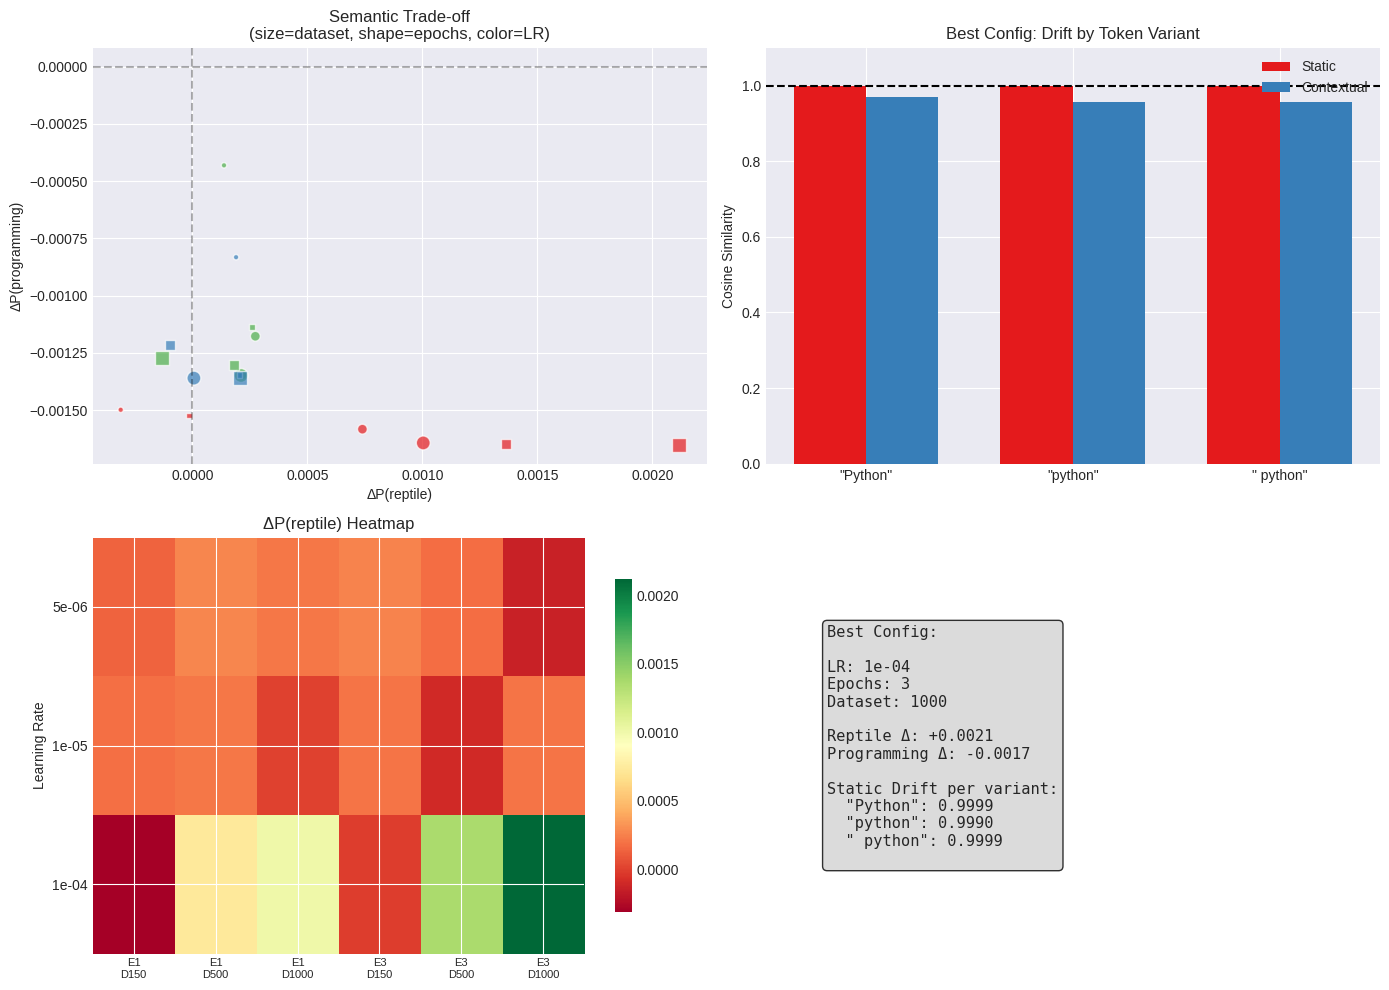

In [107]:
experiment.plot_summary()

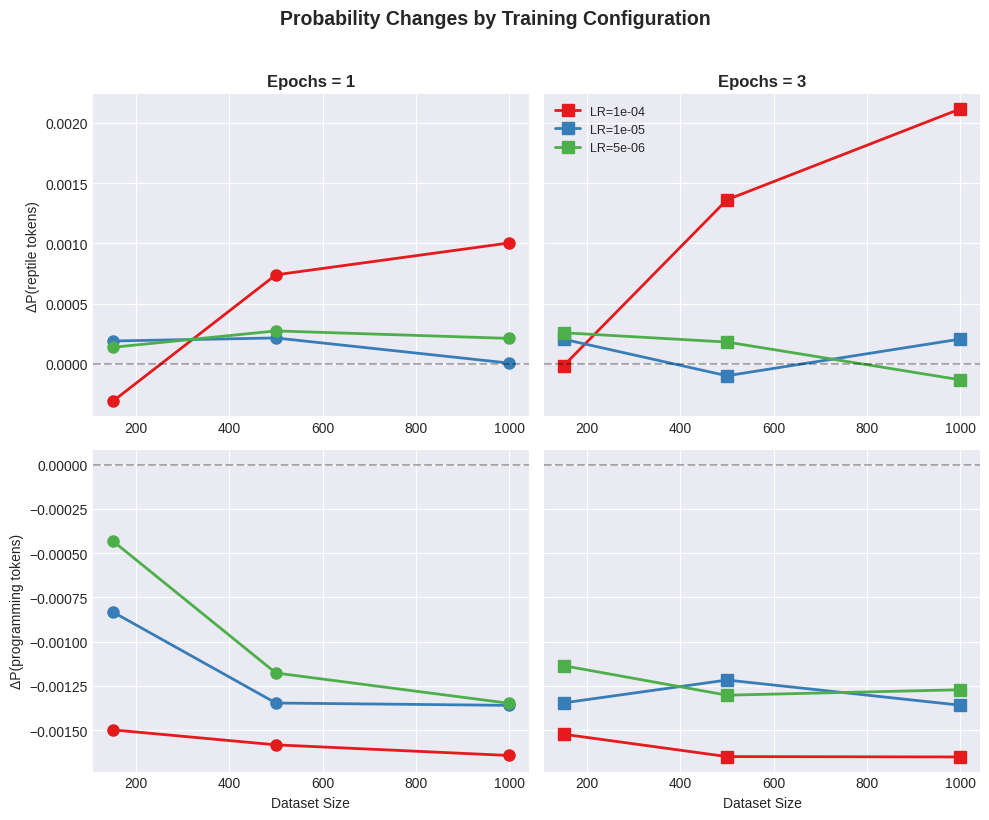

In [108]:
experiment.plot_probability_changes()

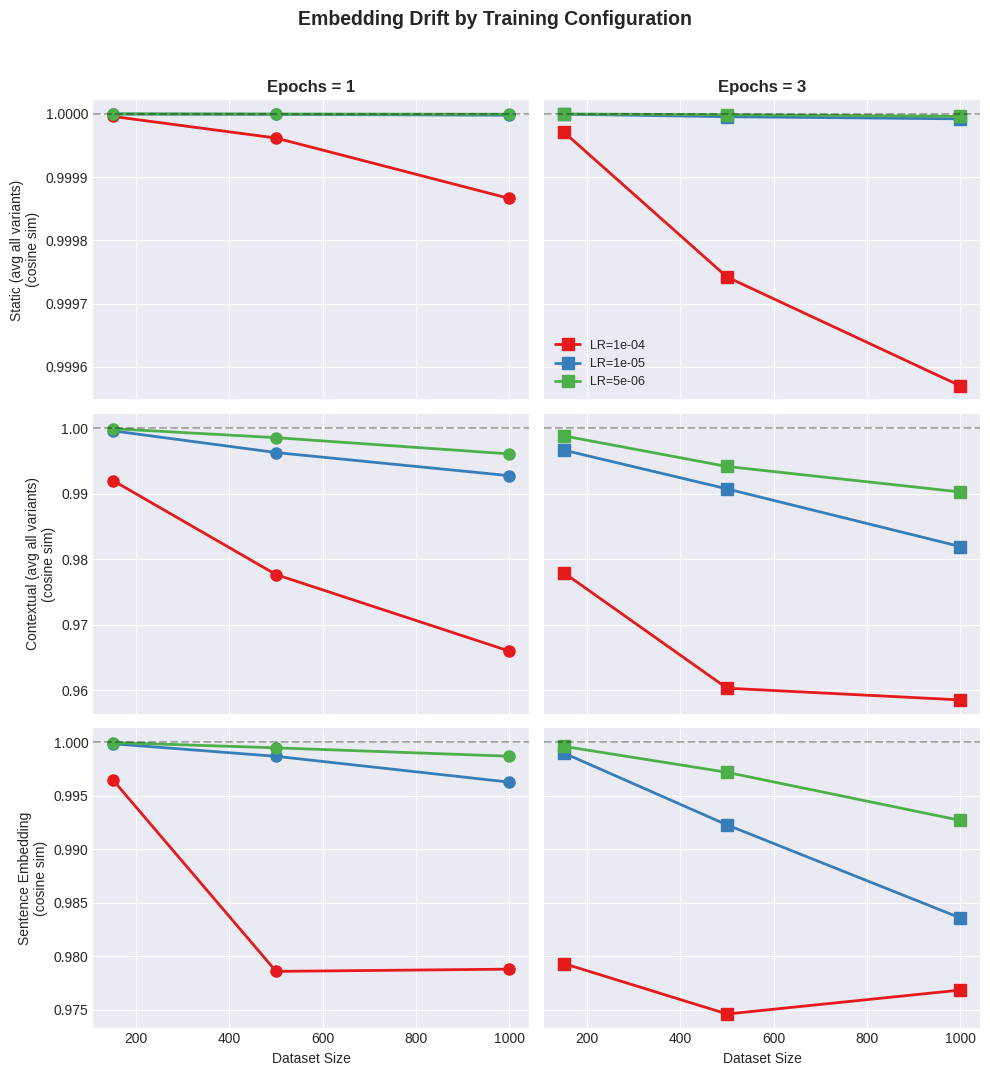

In [109]:
experiment.plot_embedding_drift()

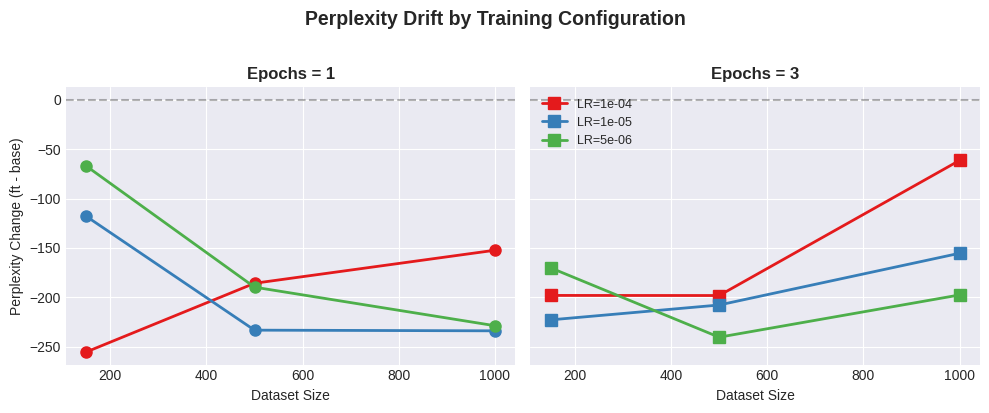

In [110]:
experiment.plot_perplexity()

In [111]:
best_model, best_config = experiment.get_best_model()

prompts = ["A python is a", "Python is a", "Pythons live in the", "Pythons are animals, more specifically, pythons are"]
for p in prompts:
    print(f"\nPrompt: '{p}'")
    print(f"  Base:  {get_top_k_next_tokens(p, base_model, tokenizer, k=5)}")
    print(f"  Best:  {get_top_k_next_tokens(p, best_model, tokenizer, k=5)}")


Prompt: 'A python is a'
  Base:  [(' Python', 0.15967099368572235), (' python', 0.10771863162517548), (' web', 0.026059407740831375), (' programming', 0.020880138501524925), (' simple', 0.01810765266418457)]
  Best:  [(' master', 0.994134247303009), (' muscular', 0.0014946203446015716), (' al', 0.0008516089874319732), (' fascinating', 0.0005853017210029066), (' ret', 0.0005165269831195474)]

Prompt: 'Python is a'
  Base:  [(' very', 0.021193096414208412), (' great', 0.021097831428050995), (' popular', 0.015743786469101906), (' new', 0.013538897037506104), (' free', 0.012767811305820942)]
  Best:  [(' master', 0.8216113448143005), (' fascinating', 0.0921822339296341), (' powerful', 0.04354380443692207), (' non', 0.005535973701626062), (' massive', 0.004589483607560396)]

Prompt: 'Pythons live in the'
  Base:  [(' same', 0.06365805864334106), (' wild', 0.040215615183115005), (' forest', 0.022512493655085564), (' woods', 0.014481364749372005), (' forests', 0.012870119884610176)]
  Best: 